# Purpose
This notebook generates supplementary figures for the control conditions (Fig S3-S11).

In [1]:
import pickle
import numpy as np
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

import sys
sys.path.append("..")
from scripts import draw, intuition, basic_components as bcomp

In [2]:
cond_ls = ['A', 'C'] # Weight adjustment condition
eta = 10.0 # learning rate
K = 30 # number of instances

num_bins = 20 # number of bins on the logscale for the histogram of the upper tail of the weight distribution
dist_ls = ['Expon', 'InvNormal', 'Normal', 'Gamma', 'InvGamma', 'Lognorm', 'Weibull'] # candidate distributions
sig_thresh = 0.05 # significance level
k_rep = 0 # the index of the representative network

# Control condition 1: adaptive weight adjustment with fixed connectivity

In [3]:
# Import resulted networks at the end of simulations
tau_ls = [0.05, 0.1, 0.5]
A_wAdjAlone = {}
for cond in cond_ls:
    A_wAdjAlone[cond] = {}
    for tau in tau_ls:
        f = open('./Output/wAdjust_alone/'+cond+'_eta_'+str(eta)+'_tau_'+str(tau)+'_'+str(k_rep)+'.pckl', 'rb')
        A_wAdjAlone[cond][tau], _ = pickle.load(f)
        f.close()

## Fig S3: Histogram of weight distributions at $\tau_{reweight}=0.05$

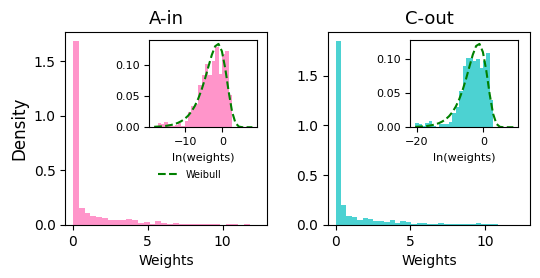

In [4]:
plt.rcParams["figure.figsize"] = (6, 2.5)
fig, ax1 = plt.subplots(1, 2)

tau = 0.05 # tau_reweight
cond_color = ['hotpink', 'c']; cond_label = ['A-in', 'C-out']

for s, cond in enumerate(cond_ls):
    # Histogram of the representative networks
    weights = A_wAdjAlone[cond][tau][A_wAdjAlone[cond][tau]>0]
    ax1[s].hist(weights, bins=30, density=True,color = cond_color[s], alpha=0.7)
    ax1[s].set_title(cond_label[s], fontsize = 13)
    ax1[s].set_xlabel('Weights',fontsize=10)
    ax1[s].tick_params(axis = 'both', labelsize=10)
    ax1[s].set_xlim([-0.5, 13])
    ax1[s].set_xlabel('Weights',fontsize=10)
    # histogram of log(weights)
    left, bottom, width, height = [0.265 + s * 0.435, 0.5, 0.18, 0.35]
    ax1_1 = fig.add_axes([left, bottom, width, height])
    x, mu, sig = draw.hist_log_weight(ax1_1, weights, num_bins = 30, color = cond_color[s])

    # the best fit distribution
    c, loc, scale = stats.weibull_min.fit(weights, floc = 0)
    yw = stats.weibull_min.pdf(np.exp(x), c, loc, scale) * np.exp(x)
    ax1_1.plot(x, yw, linestyle='dashed', color = 'g', label = 'Weibull')
    if s == 0:
        ax1_1.legend(fontsize = 7, bbox_to_anchor=[0, -0.7], loc='lower left', frameon=False)

ax1[0].set_ylabel('Density',fontsize=12)
fig.subplots_adjust(wspace = 0.3)
#plt.savefig('../fig/Fig S3.svg', dpi = 300)

## Fig S4: Histogram of weight distributions and power-law fits of C-out condition

In [5]:
f = open('./Output/wAdjust_alone/PL_fit.pckl', 'rb')
res_PL, PL_expon = pickle.load(f)
f.close()

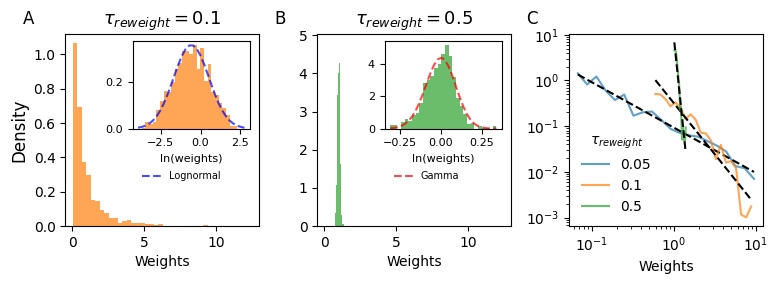

In [6]:
plt.rcParams["figure.figsize"] = (9, 2.5)
fig, ax1 = plt.subplots(1, 3)

cond = 'C'
# Histograms of the representative networks from the A-in condition
for l, tau in enumerate([0.1, 0.5]):
    weights = A_wAdjAlone[cond][tau][A_wAdjAlone[cond][tau]>0]
    ax1[l].hist(weights, bins=30, density=True,color = sns.color_palette(palette='tab10', n_colors=3)[l+1], alpha=0.7)
    ax1[l].set_title('$\\tau_{reweight} = $'+str(tau), fontsize = 13)
    ax1[l].set_xlabel('Weights',fontsize=10)
    ax1[l].tick_params(axis = 'both', labelsize=10)
    ax1[l].set_xlim([-0.5, 13])
    
    # histogram of log(weights)
    left, bottom, width, height = [0.2+l*0.28, 0.5, 0.13, 0.35]
    ax1_1 = fig.add_axes([left, bottom, width, height])
    x, mu, sig = draw.hist_log_weight(ax1_1, weights, num_bins = 30, color = sns.color_palette(palette='tab10', n_colors=3)[l+1])
    # the best fit distribution
    if l == 0:
        ylog = stats.norm.pdf(x, loc=mu, scale=sig)
        ax1_1.plot(x, ylog, color='b', linestyle='dashed',alpha=0.7, label = 'Lognormal')
    else:
        a, loc, scale = stats.gamma.fit(weights, floc = 0)
        yig = stats.gamma.pdf(np.exp(x), a, loc, scale) * np.exp(x)
        ax1_1.plot(x, yig, color='r', linestyle='dashed',alpha=0.7, label = 'Gamma')
    ax1_1.legend(fontsize = 7, bbox_to_anchor=[0, -0.7], loc='lower left', frameon=False)
ax1[0].set_ylabel('Density',fontsize=12)

# Draw power-law fits of the representative networks
for l, tau in enumerate([0.05, 0.1, 0.5]):
    weights = A_wAdjAlone[cond][tau][A_wAdjAlone[cond][tau]>0]
    res = res_PL[cond][tau].iloc[k_rep]
    draw.draw_power_law(ax1[2], weights, res, tau, num_bins, color=sns.color_palette(palette='tab10', n_colors=5)[l], draw_fit=True)
ax1[2].set_xscale('log')
ax1[2].set_yscale('log')
ax1[2].legend(title = '$\\tau_{reweight}$', frameon=False)
ax1[2].set_xlabel('Weights',fontsize=10)

ax1[0].text(-0.22, 1.05, 'A', transform=ax1[0].transAxes, size=12)
ax1[1].text(-0.22, 1.05, 'B', transform=ax1[1].transAxes, size=12)
ax1[2].text(-0.22, 1.05, 'C', transform=ax1[2].transAxes, size=12)
fig.subplots_adjust(wspace = 0.3)
#plt.savefig('../fig/Fig S4.svg', dpi = 300)

## Fig S5: Model comparison

In [8]:
f = open('./Output/wAdjust_alone/KS_stats.pckl', 'rb')
KS_stats, wilcoxon_p = pickle.load(f)
f.close()

f = open('./Output/wAdjust_alone/weibull_fit_tau_0.05.pckl', 'rb')
wb_params = pickle.load(f)
f.close()

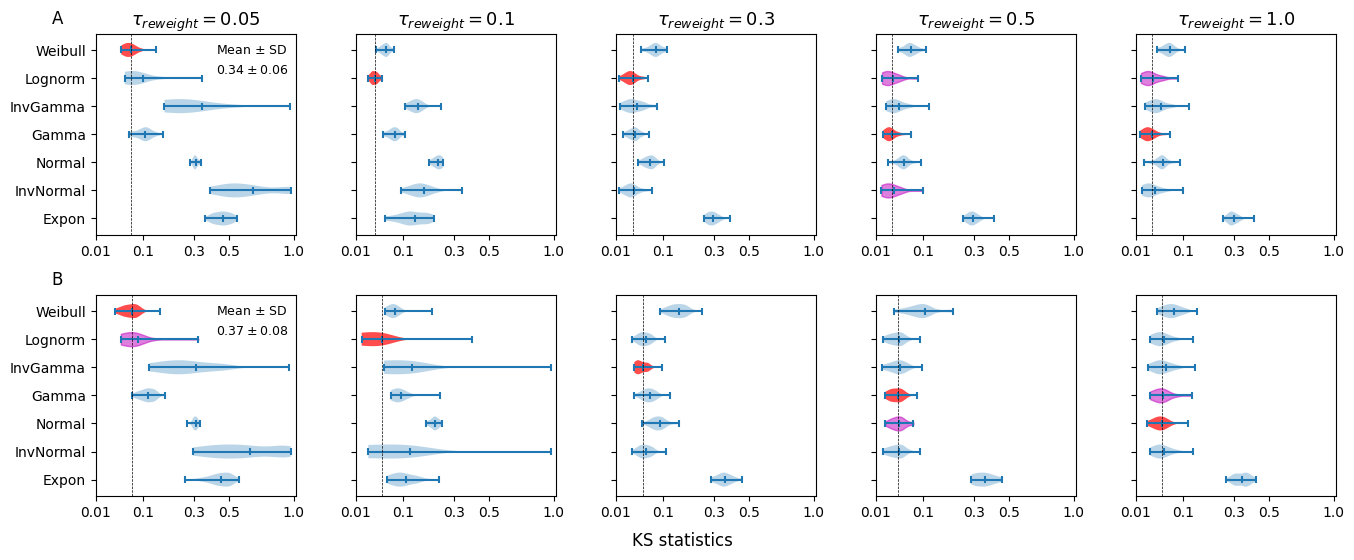

In [9]:
plt.rcParams["figure.figsize"] = (16, 6)
fig, ax1 = plt.subplots(2, 5)

for s, cond in enumerate(cond_ls):
    # Plot the KS statistics
    for i, tau in enumerate([0.05, 0.1, 0.3, 0.5, 1.0]):
        draw.draw_KS_stats(ax1[s, i], KS_stats[cond][tau], wilcoxon_p[cond][tau], sig_thresh, xmin=0.01, xmax=1.02)
        ax1[s, i].set_xticks([0.01, 0.1, 0.3, 0.5, 1.0], labels= [0.01, 0.1, 0.3, 0.5, 1.0])
        if s == 0:
            ax1[s, i].set_title('$\\tau_{reweight} = $'+str(tau), fontsize = 13)
    ax1[s, 0].set_yticks([l + 1 for l, dist in enumerate(dist_ls)], labels= dist_ls)

    # Add the estimated parameters of Weibull fit at tau_reweight=0.05
    ax1[s, 0].text(0.6, 0.9, 'Mean $\\pm$ SD', transform=ax1[s, 0].transAxes, fontsize=9)
    ax1[s, 0].text(0.6, 0.8, fr"${wb_params[cond]['loc']:.2f} \pm {wb_params[cond]['scale']:.2f}$", transform=ax1[s, 0].transAxes, fontsize=9)

ax1[0, 0].text(-0.22, 1.05, 'A', transform=ax1[0, 0].transAxes, size=12)
ax1[1, 0].text(-0.22, 1.05, 'B', transform=ax1[1, 0].transAxes, size=12)
ax1[1, 2].text(0.08, -0.25, 'KS statistics', transform=ax1[1, 2].transAxes, size=12)

fig.subplots_adjust(wspace = 0.3, hspace = 0.3)
#plt.savefig('../fig/Fig S5.svg', dpi = 300)

## Fig S6: Stationary analysis

In [10]:
f = open('./Output_long/wAdjust_alone/summary_stats_evol.pckl', 'rb')
std, skew, kurt = pickle.load(f)
f.close()

f = open('./Output_long/wAdjust_alone/Topo_metrics_evol.pckl', 'rb')
cc, ae, mod = pickle.load(f)
f.close()

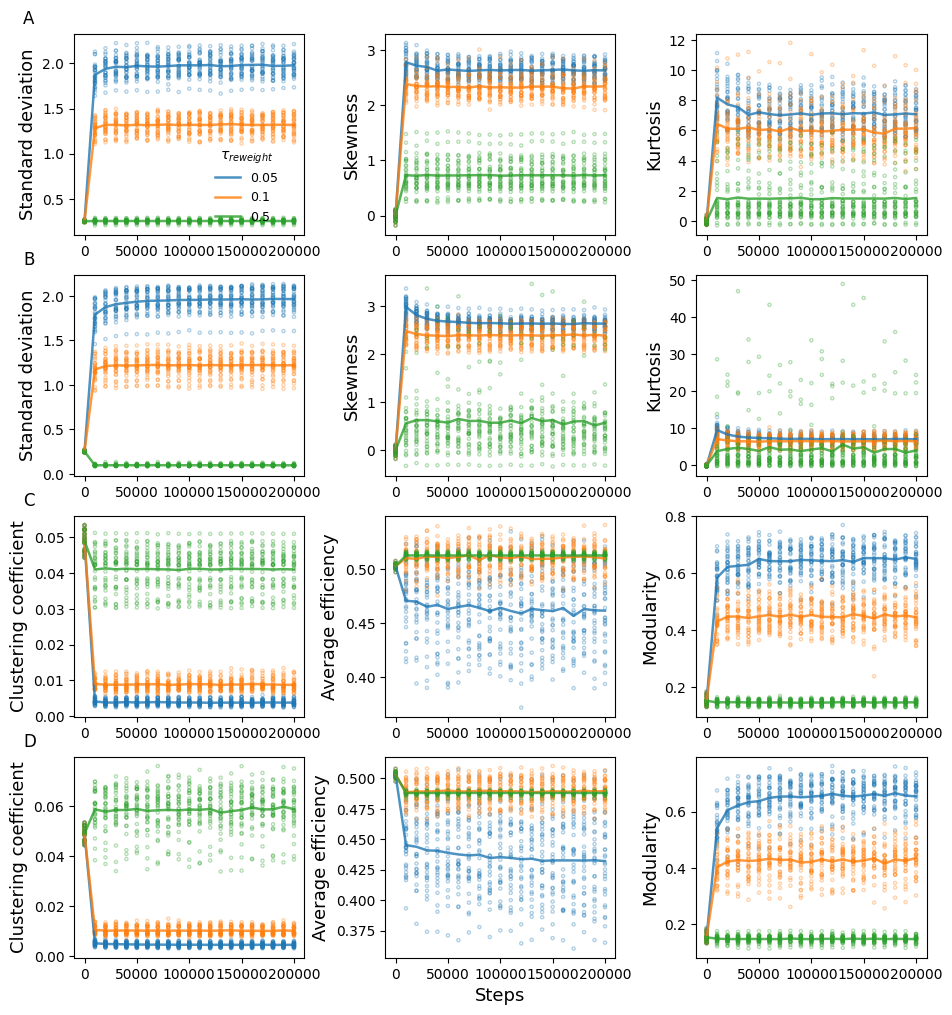

In [ ]:
plt.rcParams["figure.figsize"] = (11, 12)
fig, ax1 = plt.subplots(4, 3)
for l, cond in enumerate(cond_ls):
    for s, tau in enumerate(tau_ls):
        draw.draw_mean_scatter(ax1[l, 0], list(std[cond][tau].keys()), std[cond][tau], color = sns.color_palette(palette='tab10', n_colors=3)[s], 
                               label=str(tau), shift = 0, jitter = 1)
        draw.draw_mean_scatter(ax1[l, 1], list(skew[cond][tau].keys()), skew[cond][tau], color = sns.color_palette(palette='tab10', n_colors=3)[s], 
                               label=str(tau), shift = 0, jitter = 1)
        draw.draw_mean_scatter(ax1[l, 2], list(kurt[cond][tau].keys()), kurt[cond][tau], color = sns.color_palette(palette='tab10', n_colors=3)[s], 
                               label=str(tau), shift = 0, jitter = 1)
        draw.draw_mean_scatter(ax1[l+2, 0], list(cc[cond][tau].keys()), cc[cond][tau], color = sns.color_palette(palette='tab10', n_colors=3)[s], 
                               label=str(tau), shift = 0, jitter = 1)
        draw.draw_mean_scatter(ax1[l+2, 1], list(ae[cond][tau].keys()), ae[cond][tau], color = sns.color_palette(palette='tab10', n_colors=3)[s], 
                               label=str(tau), shift = 0, jitter = 1)
        draw.draw_mean_scatter(ax1[l+2, 2], list(mod[cond][tau].keys()), mod[cond][tau], color = sns.color_palette(palette='tab10', n_colors=3)[s], 
                               label=str(tau), shift = 0, jitter = 1)
        
    ax1[l, 0].set_ylabel('Standard deviation', fontsize = 13)
    ax1[l, 1].set_ylabel('Skewness', fontsize = 13)
    ax1[l, 2].set_ylabel('Kurtosis', fontsize = 13)
    ax1[l+2, 0].set_ylabel('Clustering coefficient', fontsize = 13)
    ax1[l+2, 1].set_ylabel('Average efficiency', fontsize = 13)
    ax1[l+2, 2].set_ylabel('Modularity', fontsize = 13)

ax1[0, 0].legend(title = '$\\tau_{reweight}$', fontsize=9, frameon=False, bbox_to_anchor=(0.5, 0., 0.5, 0.5))
ax1[3, 1].set_xlabel('Steps', fontsize = 13)

ax1[0, 0].text(-0.22, 1.05, 'A', transform=ax1[0, 0].transAxes, size=12)
ax1[1, 0].text(-0.22, 1.05, 'B', transform=ax1[1, 0].transAxes, size=12)
ax1[2, 0].text(-0.22, 1.05, 'C', transform=ax1[2, 0].transAxes, size=12)
ax1[3, 0].text(-0.22, 1.05, 'D', transform=ax1[3, 0].transAxes, size=12)
for i in range(4):
    for j in range(3):
        ax1[i, j].ticklabel_format(axis='x', style='sci', scilimits=(0, 0))

fig.subplots_adjust(wspace = 0.35, hspace = 0.2)
#plt.savefig('../fig/Fig S6.svg', dpi = 300)

# Control condition 2: Random rewiring + adaptive weight adjustment

## Fig S7: Histogram of weight distribution and power-law fits of the upper tails

In [ ]:
# Import resulted networks at the end of simulations
tau_ls = [0.05, 0.1, 0.5]
A_randAdapt = {}
for cond in cond_ls:
    A_randAdapt[cond] = {}
    for tau in tau_ls:
        f = open('./Output/wAdjust_randRew/'+cond+'_eta_'+str(eta)+'_tau_'+str(tau)+'_'+str(k_rep)+'.pckl', 'rb')
        A_randAdapt[cond][tau], _ = pickle.load(f)
        f.close()

In [14]:
f = open('./Output/wAdjust_randRew/PL_fit.pckl', 'rb')
res_PL, PL_expon = pickle.load(f)
f.close()

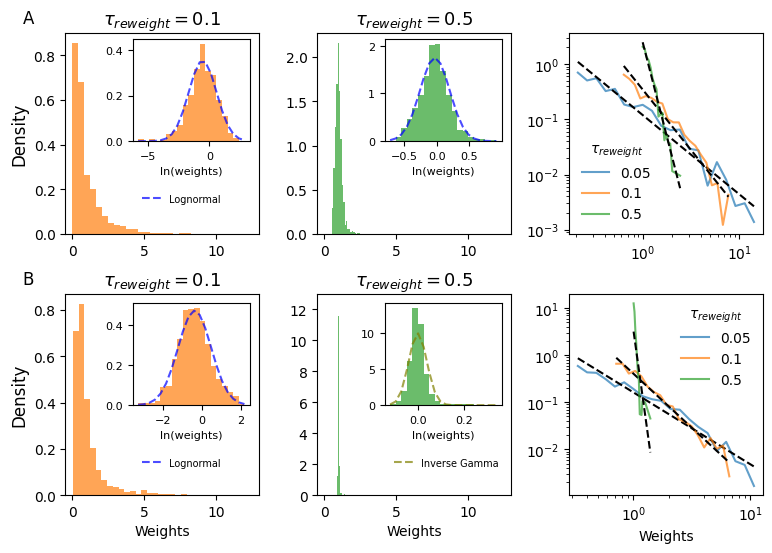

In [15]:
plt.rcParams["figure.figsize"] = (9, 6)
fig, ax1 = plt.subplots(2, 3)

k = 0
for s, cond in enumerate(cond_ls):
    for l, tau in enumerate([0.1, 0.5]):
        # Histograms of the representative networks
        weights = A_randAdapt[cond][tau][A_randAdapt[cond][tau]>0]
        ax1[s, l].hist(weights, bins=20, density=True,color = sns.color_palette(palette='tab10', n_colors=3)[l+1], alpha=0.7)
        ax1[s, l].set_title('$\\tau_{reweight} = $'+str(tau), fontsize = 13)
        ax1[s, l].tick_params(axis = 'both', labelsize=10)
        ax1[s, l].set_xlim([-0.5, 13])

        left, bottom, width, height = [0.2+l*0.28, 0.7 - s * 0.44, 0.13, 0.17]
        ax1_1 = fig.add_axes([left, bottom, width, height])
        # histogram of log(weights)
        x, mu, sig = draw.hist_log_weight(ax1_1, weights, num_bins = 20, color = sns.color_palette(palette='tab10', n_colors=3)[l+1])
        # the best fit distribution
        if s == 0:
            ylog = stats.norm.pdf(x, loc=mu, scale=sig)
            ax1_1.plot(x, ylog, color='b', linestyle='dashed',alpha=0.7, label = 'Lognormal')
            if l == 0:
                ax1_1.legend(fontsize = 7, bbox_to_anchor=[0, -0.7], loc='lower left', frameon=False)
        else:
            if l == 0:
                ylog = stats.norm.pdf(x, loc=mu, scale=sig)
                ax1_1.plot(x, ylog, color='b', linestyle='dashed',alpha=0.7, label = 'Lognormal')
            else:
                a, loc, scale = stats.invgamma.fit(weights, floc = 0)
                yig = stats.invgamma.pdf(np.exp(x), a, loc, scale) * np.exp(x)
                ax1_1.plot(x, yig, color='olive', linestyle='dashed',alpha=0.7, label = 'Inverse Gamma')
            ax1_1.legend(fontsize = 7, bbox_to_anchor=[0, -0.7], loc='lower left', frameon=False)
    ax1[s, 0].set_ylabel('Density',fontsize=12)

    # Draw power-law fits of the representative networks
    for l, tau in enumerate([0.05, 0.1, 0.5]):
        weights = A_randAdapt[cond][tau][A_randAdapt[cond][tau]>0]
        res = res_PL[cond][tau].iloc[k_rep]
        draw.draw_power_law(ax1[s, 2], weights, res, tau, num_bins, color = sns.color_palette(palette='tab10', n_colors=5)[l], draw_fit=True)
        
    ax1[s, 2].set_xscale('log')
    ax1[s, 2].set_yscale('log')
    ax1[s, 2].legend(title = '$\\tau_{reweight}$', frameon=False)

for l in range(3):
    ax1[1, l].set_xlabel('Weights',fontsize=10)
ax1[0, 0].text(-0.22, 1.05, 'A', transform=ax1[0, 0].transAxes, size=12)
ax1[1, 0].text(-0.22, 1.05, 'B', transform=ax1[1, 0].transAxes, size=12)
fig.subplots_adjust(wspace = 0.3, hspace = 0.3)
#plt.savefig('../fig/Fig S7.svg', dpi = 300)

## Fig S8: Topological metrics

In [16]:
f = open('./Output/wAdjust_randRew/Topo_metrics.pckl', 'rb')
cc_null_norm, ae_null_norm, sw_null_norm, mod_null_norm = pickle.load(f)
f.close()

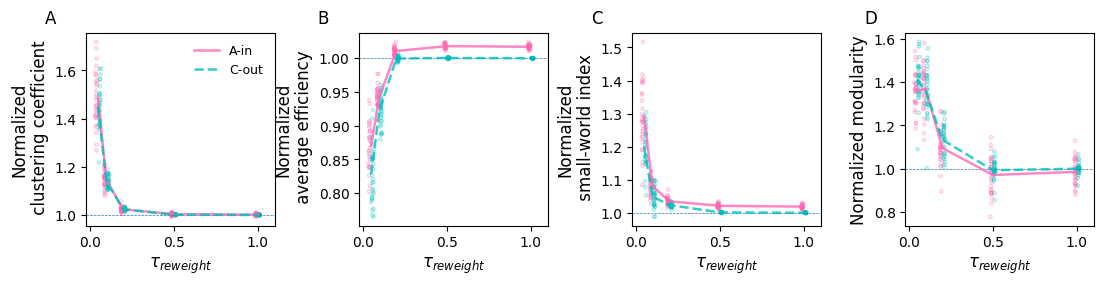

In [17]:
tau_ls = [0.05, 0.1, 0.2, 0.5, 1.0]
cond_color = ['hotpink', 'c']; cond_label = ['A-in', 'C-out']; cond_linestyle = ['-', '--']

plt.rcParams["figure.figsize"] = (13, 2.5)
fig, ax1 = plt.subplots(1, 4)

for s, cond in enumerate(cond_ls):
    draw.draw_mean_scatter(ax1[0], tau_ls, cc_null_norm[cond], color = cond_color[s], label = cond_label[s],
    linestyle = cond_linestyle[s], shift = ((-1)**s)*0.01, jitter = 0.003)
    draw.draw_mean_scatter(ax1[1], tau_ls, ae_null_norm[cond], color = cond_color[s], label = cond_label[s],
    linestyle = cond_linestyle[s], shift = ((-1)**s)*0.01, jitter = 0.003)
    draw.draw_mean_scatter(ax1[2], tau_ls, sw_null_norm[cond], color = cond_color[s], label = cond_label[s],
    linestyle = cond_linestyle[s], shift = ((-1)**s)*0.01, jitter = 0.003)
    draw.draw_mean_scatter(ax1[3], tau_ls, mod_null_norm[cond], color = cond_color[s], label = cond_label[s],
    linestyle = cond_linestyle[s], shift = ((-1)**s)*0.01, jitter = 0.003)

for l in range(4):
    ax1[l].axhline(y = 1, ls = '--', lw = 0.5)
    ax1[l].set_xlim([-0.02,1.1])
    ax1[l].set_xlabel('$\\tau_{reweight}$', fontsize = 12)
ax1[0].legend(fontsize=9, frameon=False)
ax1[0].set_ylabel('Normalized\n clustering coefficient', fontsize = 12)
ax1[1].set_ylabel('Normalized\n average efficiency', fontsize = 12)
ax1[2].set_ylabel('Normalized\n small-world index', fontsize = 12)
ax1[3].set_ylabel('Normalized modularity', fontsize = 12)
ax1[0].text(-0.22, 1.05, 'A', transform=ax1[0].transAxes, size=12)
ax1[1].text(-0.22, 1.05, 'B', transform=ax1[1].transAxes, size=12)
ax1[2].text(-0.22, 1.05, 'C', transform=ax1[2].transAxes, size=12)
ax1[3].text(-0.22, 1.05, 'D', transform=ax1[3].transAxes, size=12)

fig.subplots_adjust( wspace = 0.45)
#plt.savefig('../fig/Fig S8.svg', dpi = 300)

## Fig S9: Stationary analysis

In [18]:
f = open('./Output_long/wAdjust_randRew/summary_stats_evol.pckl', 'rb')
std, skew, kurt = pickle.load(f)
f.close()

f = open('./Output_long/wAdjust_randRew/Topo_metrics_evol.pckl', 'rb')
cc, ae, mod = pickle.load(f)
f.close()

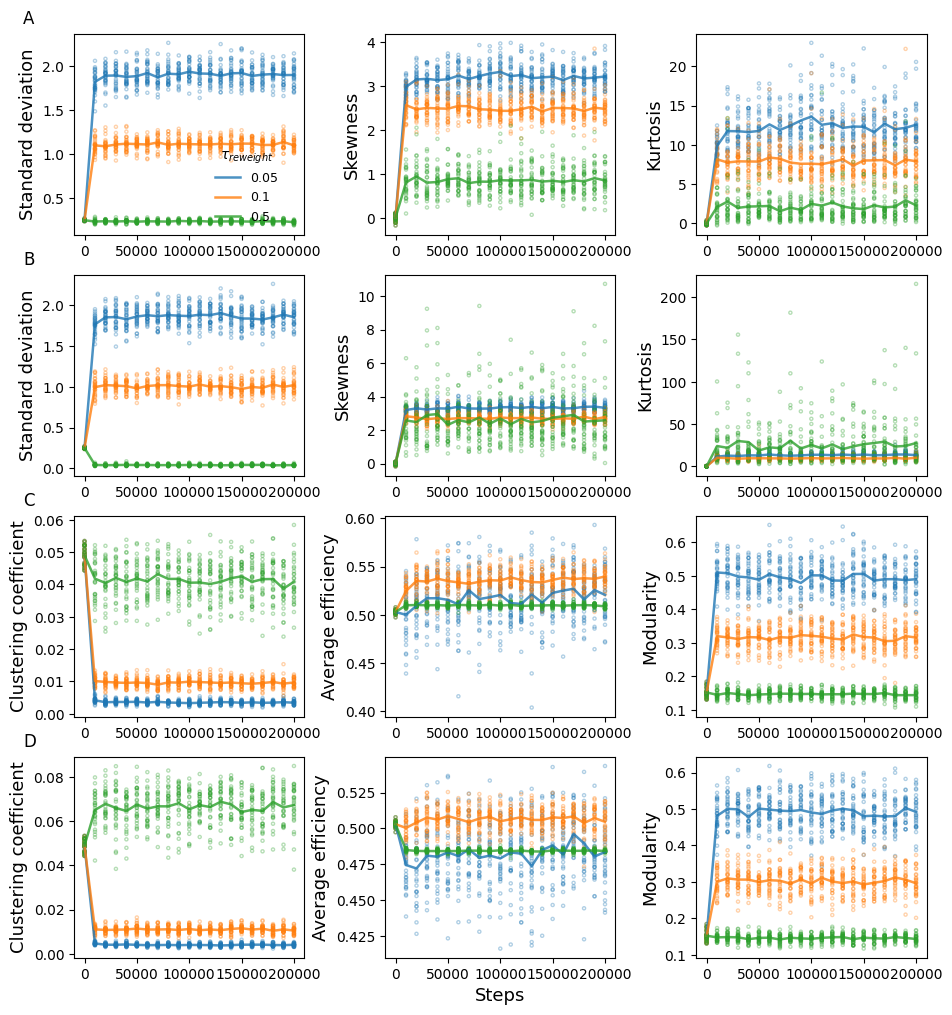

In [ ]:
tau_ls = [0.05, 0.1, 0.5]

plt.rcParams["figure.figsize"] = (11, 12)
fig, ax1 = plt.subplots(4, 3)
for l, cond in enumerate(cond_ls):
    for s, tau in enumerate(tau_ls):
        draw.draw_mean_scatter(ax1[l, 0], list(std[cond][tau].keys()), std[cond][tau], color = sns.color_palette(palette='tab10', n_colors=3)[s], 
                               label=str(tau), shift = 0, jitter = 1)
        draw.draw_mean_scatter(ax1[l, 1], list(skew[cond][tau].keys()), skew[cond][tau], color = sns.color_palette(palette='tab10', n_colors=3)[s], 
                               label=str(tau), shift = 0, jitter = 1)
        draw.draw_mean_scatter(ax1[l, 2], list(kurt[cond][tau].keys()), kurt[cond][tau], color = sns.color_palette(palette='tab10', n_colors=3)[s], 
                               label=str(tau), shift = 0, jitter = 1)
        draw.draw_mean_scatter(ax1[l+2, 0], list(cc[cond][tau].keys()), cc[cond][tau], color = sns.color_palette(palette='tab10', n_colors=3)[s], 
                               label=str(tau), shift = 0, jitter = 1)
        draw.draw_mean_scatter(ax1[l+2, 1], list(ae[cond][tau].keys()), ae[cond][tau], color = sns.color_palette(palette='tab10', n_colors=3)[s], 
                               label=str(tau), shift = 0, jitter = 1)
        draw.draw_mean_scatter(ax1[l+2, 2], list(mod[cond][tau].keys()), mod[cond][tau], color = sns.color_palette(palette='tab10', n_colors=3)[s], 
                               label=str(tau), shift = 0, jitter = 1)
        
    ax1[l, 0].set_ylabel('Standard deviation', fontsize = 13)
    ax1[l, 1].set_ylabel('Skewness', fontsize = 13)
    ax1[l, 2].set_ylabel('Kurtosis', fontsize = 13)
    ax1[l+2, 0].set_ylabel('Clustering coefficient', fontsize = 13)
    ax1[l+2, 1].set_ylabel('Average efficiency', fontsize = 13)
    ax1[l+2, 2].set_ylabel('Modularity', fontsize = 13)

ax1[0, 0].legend(title = '$\\tau_{reweight}$', fontsize=9, frameon=False, bbox_to_anchor=(0.5, 0., 0.5, 0.5))
ax1[3, 1].set_xlabel('Steps', fontsize = 13)

ax1[0, 0].text(-0.22, 1.05, 'A', transform=ax1[0, 0].transAxes, size=12)
ax1[1, 0].text(-0.22, 1.05, 'B', transform=ax1[1, 0].transAxes, size=12)
ax1[2, 0].text(-0.22, 1.05, 'C', transform=ax1[2, 0].transAxes, size=12)
ax1[3, 0].text(-0.22, 1.05, 'D', transform=ax1[3, 0].transAxes, size=12)
for i in range(4):
    for j in range(3):
        ax1[i, j].ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
        
fig.subplots_adjust(wspace = 0.35, hspace = 0.2)
#plt.savefig('../fig/Fig S9.svg', dpi = 300)

# Intuitive explanation

## Fig S10: Weight increments are approximately proportional to connection weights only at small $\tau_{reweight}$ in a random network.

In [20]:
f = open('./Output/inits.pckl', 'rb')
inits = pickle.load(f)
f.close()

In [21]:
n = 100 # number of nodes
A0 = inits[0].copy() # an initial random network
w = A0[A0>0] # weights of this network, following a normal distribution

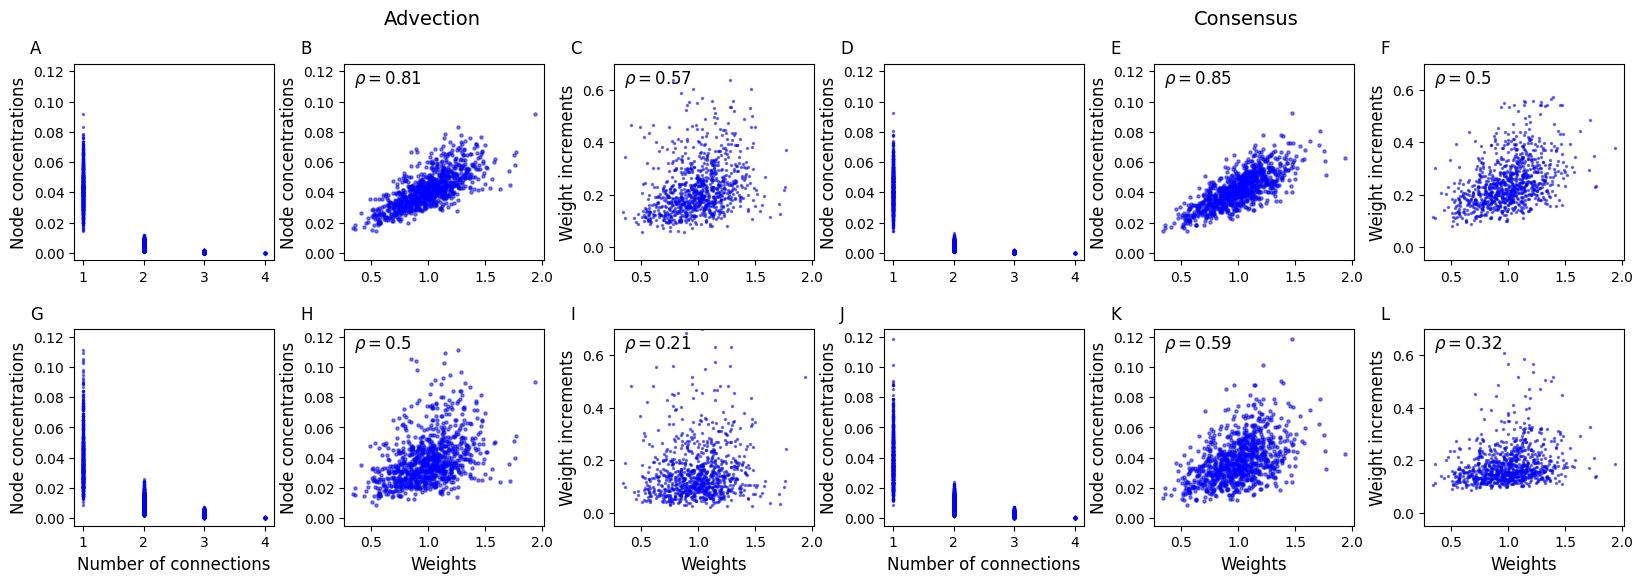

In [22]:
plt.rcParams["figure.figsize"] = (20, 6)
fig, ax1 = plt.subplots(2, 6)

steps = intuition.step_mat(A0) # matrix containing the number of steps between two nodes
positive_steps = steps[steps>0] # steps of existing paths

for m, tau in enumerate([0.1, 0.2]):
    # relation between node states and the number of steps the node from the activity source
    adv_kernel = bcomp.advection_kernel(A0, tau)
    positive_kernel_val = adv_kernel[steps>0] # when activity starts at a node, the states at time tau of nodes it can reach
    ax1[m, 0].scatter(positive_steps, positive_kernel_val, s=2, c='b', alpha = 0.5)
    ax1[m, 0].set_ylabel('Node concentrations', fontsize = 12)
    ax1[m, 0].set_ylim([-0.005, 0.125])

    con_kernel = bcomp.consensus_kernel(A0, tau)
    positive_kernel_val = con_kernel[steps>0] # when activity starts at a node, the states at time tau of nodes it can reach
    ax1[m, 3].scatter(positive_steps, positive_kernel_val, s=2, c='b', alpha = 0.5)
    ax1[m, 3].set_ylabel('Node concentrations', fontsize = 12)
    ax1[m, 3].set_ylim([-0.005, 0.125])

    # relation between node states and connection weights
    weight_ls, kernel_ls, rho = intuition.kernel_weight_relation(A0, adv_kernel, flag = 'Advection')
    ax1[m, 1].scatter(weight_ls, kernel_ls, s = 5, c='b', alpha = 0.5)
    ax1[m, 1].text(0.05, 0.9, '$\\rho=$'+str(np.round(rho, 2)), transform=ax1[m, 1].transAxes, size=12)
    ax1[m, 1].set_ylabel('Node concentrations', fontsize = 12)
    ax1[m, 1].set_ylim([-0.005, 0.125])

    weight_ls, kernel_ls, rho = intuition.kernel_weight_relation(A0, con_kernel, flag = 'Consensus')
    ax1[m, 4].scatter(weight_ls, kernel_ls, s = 5, c='b', alpha = 0.5)
    ax1[m, 4].text(0.05, 0.9, '$\\rho=$'+str(np.round(rho, 2)), transform=ax1[m, 4].transAxes, size=12)
    ax1[m, 4].set_ylabel('Node concentrations', fontsize = 12)
    ax1[m, 4].set_ylim([-0.005, 0.125])

    # relation between weight increments and connection weights
    weight_ls, weight_increment_ls, rho = intuition.increment_weight_relation(A0, adv_kernel, eta, flag = 'Advection')
    ax1[m, 2].scatter(weight_ls, weight_increment_ls, s=2, c='b', alpha = 0.5)
    ax1[m, 2].text(0.05, 0.9, '$\\rho=$'+str(np.round(rho, 2)), transform=ax1[m, 2].transAxes, size=12)
    ax1[m, 2].set_ylabel('Weight increments', fontsize = 12)
    ax1[m, 2].set_ylim([-0.05, 0.7])

    weight_ls, weight_increment_ls, rho = intuition.increment_weight_relation(A0, con_kernel, eta, flag = 'Consensus')
    ax1[m, 5].scatter(weight_ls, weight_increment_ls, s=2, c='b', alpha = 0.5)
    ax1[m, 5].text(0.05, 0.9, '$\\rho=$'+str(np.round(rho, 2)), transform=ax1[m, 5].transAxes, size=12)
    ax1[m, 5].set_ylabel('Weight increments', fontsize = 12)
    ax1[m, 5].set_ylim([-0.05, 0.7])

ax1[0, 0].text(-0.22, 1.05, 'A', transform=ax1[0, 0].transAxes, size=12)
ax1[0, 1].text(-0.22, 1.05, 'B', transform=ax1[0, 1].transAxes, size=12)
ax1[0, 2].text(-0.22, 1.05, 'C', transform=ax1[0, 2].transAxes, size=12)
ax1[0, 3].text(-0.22, 1.05, 'D', transform=ax1[0, 3].transAxes, size=12)
ax1[0, 4].text(-0.22, 1.05, 'E', transform=ax1[0, 4].transAxes, size=12)
ax1[0, 5].text(-0.22, 1.05, 'F', transform=ax1[0, 5].transAxes, size=12)
ax1[1, 0].text(-0.22, 1.05, 'G', transform=ax1[1, 0].transAxes, size=12)
ax1[1, 1].text(-0.22, 1.05, 'H', transform=ax1[1, 1].transAxes, size=12)
ax1[1, 2].text(-0.22, 1.05, 'I', transform=ax1[1, 2].transAxes, size=12)
ax1[1, 3].text(-0.22, 1.05, 'J', transform=ax1[1, 3].transAxes, size=12)
ax1[1, 4].text(-0.22, 1.05, 'K', transform=ax1[1, 4].transAxes, size=12)
ax1[1, 5].text(-0.22, 1.05, 'L', transform=ax1[1, 5].transAxes, size=12)
ax1[0, 1].text(0.2, 1.2, 'Advection', transform=ax1[0, 1].transAxes, size=14)
ax1[0, 4].text(0.2, 1.2, 'Consensus', transform=ax1[0, 4].transAxes, size=14)
ax1[1, 0].set_xlabel('Number of connections', fontsize = 12)
ax1[1, 1].set_xlabel('Weights', fontsize = 12)
ax1[1, 2].set_xlabel('Weights', fontsize = 12)
ax1[1, 3].set_xlabel('Number of connections', fontsize = 12)
ax1[1, 4].set_xlabel('Weights', fontsize = 12)
ax1[1, 5].set_xlabel('Weights', fontsize = 12)
plt.subplots_adjust(wspace = 0.35, hspace = 0.35)

#plt.savefig('./fig/Fig S10.svg', dpi = 300)

## Fig S11: Node states homogenize as the time of diffusion increases.

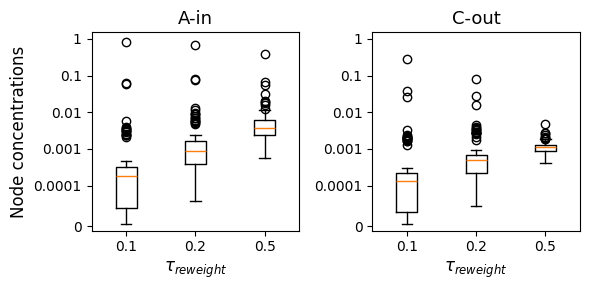

In [23]:
plt.rcParams["figure.figsize"] = (6, 3)
fig, ax1 = plt.subplots(1, 2)
m = 0 # the source of activity
tau_ls = [0.1, 0.2, 0.5] # time of diffusion before update weights

# node states at different time
C_states = {}; A_states = {}
for tau in tau_ls:
    Kc = bcomp.consensus_kernel(A0, tau)
    C_states[tau] = Kc[:, m]
    Ka = bcomp.advection_kernel(A0, tau)
    A_states[tau] = Ka[:, m]

C_states = [np.asarray(C_states[t]).ravel() for t in tau_ls]
A_states = [np.asarray(A_states[t]).ravel() for t in tau_ls]
ax1[0].boxplot(A_states, tick_labels=[str(t) for t in tau_ls], showfliers=True)
ax1[1].boxplot(C_states, tick_labels=[str(t) for t in tau_ls], showfliers=True)

ax1[0].set_yscale("symlog", linthresh=1e-4)
ax1[1].set_yscale("symlog", linthresh=1e-4)
ax1[0].set_ylim([-1e-5, 1.5])
ax1[1].set_ylim([-1e-5, 1.5])
ax1[0].set_yticks([0, 0.0001, 0.001, 0.01, 0.1, 1])
ax1[0].set_yticklabels( [str(lab) for lab in [0, 0.0001, 0.001, 0.01, 0.1, 1]])
ax1[1].set_yticks([0, 0.0001, 0.001, 0.01, 0.1, 1])
ax1[1].set_yticklabels( [str(lab) for lab in [0, 0.0001, 0.001, 0.01, 0.1, 1]])
ax1[0].set_xlabel("$\\tau_{reweight}$", size=12)
ax1[1].set_xlabel("$\\tau_{reweight}$", size=12)
ax1[1].set_title('C-out', fontsize = 13)
ax1[0].set_title('A-in', fontsize = 13)
ax1[0].set_ylabel('Node concentrations', fontsize = 12)
fig.subplots_adjust(wspace = 0.3)
plt.tight_layout()

#plt.savefig('./fig/Fig S11.svg', dpi = 300)